In [205]:
import warnings
warnings.filterwarnings('ignore')

In [206]:
import pandas as pd
import numpy as np
import pyreadr
import joblib

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

In [207]:
dem_uncont = pd.read_csv('transformed/dem_uncontested_seats.csv')
rep_uncont = pd.read_csv('transformed/rep_uncontested_seats.csv')

In [208]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont.shape[0])
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims

,seats,winner
0,220,Democrats
1,253,Democrats
2,214,Republicans
3,233,Democrats
4,234,Democrats
...,...,...
19995,202,Republicans
19996,268,Democrats
19997,210,Republicans
19998,238,Democrats


In [209]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 218 else (435-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,105,1,0.005,Republicans
1,143,1,0.005,Republicans
2,144,1,0.005,Republicans
3,149,1,0.005,Republicans
4,153,2,0.010,Republicans


In [210]:
np.unique(seat_sims['seats']).shape[0]

198

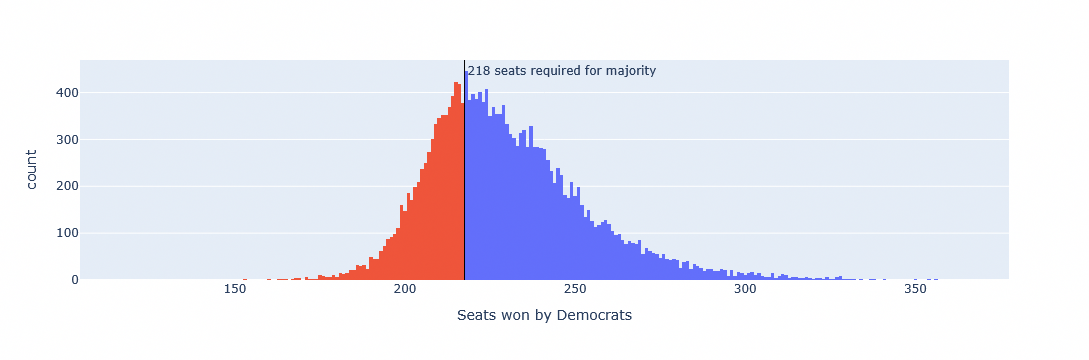

In [211]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner', 
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'})
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=217.5, line_width=1, line_color='black', annotation_text='218 seats required for majority', 
                    annotation_position='top right')
sims_hist

In [212]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [213]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,...,19990,19991,19992,19993,19994,19995,19996,19997,19998,19999
AK-AL,-4.442596,-3.088343,-7.362178,-4.513135,-1.722896,-9.741025,-0.694552,-5.915359,-3.666507,-5.331119,...,-4.221759,-4.263261,-4.506049,-4.378264,-4.178296,-8.399200,-3.172948,-7.520492,-0.831983,-0.137439
AL-01,-15.059903,-10.457452,-17.949455,-14.494757,-13.104512,-13.413788,-18.073064,-12.581569,-17.597959,-12.997327,...,-15.315782,-20.022772,-18.792648,-12.952986,-11.848282,-15.685168,-11.287392,-13.619093,-15.106122,-16.388704
AL-02,-4.057704,-1.189985,-2.736544,-4.428580,-0.060299,-5.760700,-1.643276,-4.879209,-6.683841,1.722365,...,-6.197645,-5.079480,-4.807185,-4.838744,-6.408513,-9.085681,2.035828,-7.165815,-1.484821,-3.255188
AL-03,-20.147098,-19.464917,-23.113521,-19.859432,-18.888317,-22.109428,-22.071469,-20.765322,-19.290537,-16.531866,...,-23.512385,-24.749560,-26.650523,-19.486717,-18.542922,-27.161656,-15.674083,-21.635765,-19.547277,-22.887008
AL-04,-32.018907,-26.581285,-35.143621,-36.875053,-26.298131,-34.635123,-29.925518,-31.438987,-27.108455,-30.398713,...,-34.210695,-33.895944,-34.103004,-30.587558,-29.776315,-37.944725,-28.007279,-32.110561,-30.147747,-30.806659


In [214]:
post.shape

(423, 20000)

In [215]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 218 - dem_uncont.shape[0]: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (218 - dem_uncont.shape[0])
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (435 - seats_won_dem) - (218 - rep_uncont.shape[0])
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [216]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|███████████████████████████████████████████████████████████████████████████| 20000/20000 [00:28<00:00, 690.51it/s]


array(['NY-17', 'NY-03', 'WI-01', ..., 'OH-07', 'VA-02', 'NC-09'],
      shape=(20000,), dtype='<U32')

In [217]:
data = pd.read_csv('../../model_output/house_predictions.csv')
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,-6.565250,-18.764506,-1,-37.529012,45.169784,3.721860,9.53,1,37.827369,52.480047
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,-28.528928,-38.923019,0,-77.846039,35.908672,3.688026,0.01,2,28.705429,43.158696
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,-6.698061,-19.716169,1,-39.432338,47.265020,3.583233,22.39,3,40.209580,54.277200
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",...,-39.296829,-45.710827,-1,-91.421653,29.446045,3.602375,0.00,4,22.363171,36.550607
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",...,-59.588924,-47.132870,-1,-94.265741,19.692007,3.625083,0.00,5,12.559061,26.841239


In [218]:
data['tipping_point_prob'] = data['cd'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,-18.764506,-1,-37.529012,45.169784,3.721860,9.53,1,37.827369,52.480047,0.115
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,-38.923019,0,-77.846039,35.908672,3.688026,0.01,2,28.705429,43.158696,0.000
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,-19.716169,1,-39.432338,47.265020,3.583233,22.39,3,40.209580,54.277200,0.910
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",...,-45.710827,-1,-91.421653,29.446045,3.602375,0.00,4,22.363171,36.550607,0.000
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",...,-47.132870,-1,-94.265741,19.692007,3.625083,0.00,5,12.559061,26.841239,0.000


In [219]:
data.sort_values('tipping_point_prob', ascending=False).head(7)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
197,197,MI-10,Christina Hines,Mike Bouchard,False,False,MI,10,"HINES, CHRISTINA","BOUCHARD, MICHAEL",...,-3.195838,0,-6.391676,50.361886,3.704985,54.110,198,42.946091,57.670166,3.140
233,233,NC-11,Jamie Ager,Jennifer Balkcom,False,False,NC,11,"AGER, JAMIE",no_match,...,50.000000,0,100.000000,50.821787,3.750300,58.795,234,43.446172,58.158084,3.110
37,37,CA-22,Randy Villegas,David Valadao,False,True,CA,22,"VILLEGAS, RANDY","VALADAO, DAVID",...,12.732090,-1,25.464181,50.316327,3.549280,53.850,38,43.317863,57.327945,2.725
191,191,MI-04,Sean McCann,Bill Huizenga,False,True,MI,4,"MCCANN, SEAN","HUIZENGA, WILLIAM P",...,7.674047,-1,15.348095,49.923935,3.533737,49.180,192,42.945163,56.893249,2.690
278,278,NY-17,Cait Conley,Mike Lawler,False,True,NY,17,"CONLEY, CAIT","LAWLER, MICHAEL VINCENT",...,3.773526,-1,7.547052,50.556977,3.591516,56.300,279,43.525265,57.602732,2.645
319,319,PA-07,Bob Brooks,Ryan Mackenzie,False,True,PA,7,"BROOKS, BOB","MACKENZIE, RYAN EDWARD",...,6.533790,-1,13.067581,50.175939,3.639239,52.035,320,42.923912,57.287938,2.610
194,194,MI-07,William Lawrence,Tom Barrett,False,True,MI,7,"LAWRENCE, WILLIAM","BARRETT, THOMAS MORE",...,-25.887528,-1,-51.775056,49.846608,3.609822,48.540,195,42.749621,56.889980,2.580
